# **Report assignment 10- Group 6**

## Data Augmentation

Three augmentation techniques were implemented to improve model generalization and reduce overfitting:

### 1. Mirror Augmentation (Y-Plane)
- Mirrors poses left-right by swapping and negating x-coordinates of symmetric joints
- Doubles the effective training dataset size
- **Result**: 3.6% improvement in validation MAE (0.0446 → 0.0430)

### 2. Rotation Augmentation (Around Y-Axis)
- Rotates the entire pose around the vertical (Y) axis by small angles
- Helps model become invariant to camera angle changes
- **Status**: Implemented but computationally expensive

### 3. Noise Augmentation
- Adds Gaussian noise to joint coordinates
- Smaller noise variance for Z-depth (0.001) than X/Y (0.002)
- Makes model robust to minor detection errors
- **Status**: Implemented but not tested, nodes could already have alot of noise


## Model accuracy compared to Kinect data

Despite exhaustive grid search and 18‑fold cross‑validation, depth (z) errors vary strongly across joints due to anatomical differences in range of motion, kinematic constraints, and asymmetric occlusion/motion patterns in the dataset. Joints with small depth variation (head, knee) achieve low MAE (~6 cm), while the left hand’s high MAE (~18 cm) reflects large depth excursions and frequent occlusions. The optimization minimizes average error across all joints and folds, allowing higher error on difficult joints if it reduces error on many easier ones.

|Joint | MAE (cm)|
| --- | --- |
|head_z|6.236|
|left_shoulder_z|9.317|
|left_elbow_z|8.003|
|right_shoulder_z|12.847|
|right_elbow_z|8.681|
|left_hand_z|17.744|
|right_hand_z|9.483|
|left_hip_z|13.221|
|right_hip_z|8.637|
|left_knee_z|6.341|
|right_knee_z|10.620|
|left_foot_z|11.002|
|right_foot_z|9.588|


Test metrics from NN from last week, tuned on kinect, retrained on augmented kinect data and evaluated vs test set of kinect z - see evaluate_champ_from_gridsearch.ipynb in HugoProject/notebooks

|Joint| MAE (cm) |
|-----|----------|
|head_z|4.7560|
|left_shoulder_z|4.1074|
|left_elbow_z|5.4677|
|right_shoulder_z|4.9144|
|right_elbow_z|5.5221|
|left_hand_z|6.7594|
|right_hand_z|6.2986|
|left_hip_z|4.3891|
|right_hip_z|4.2621|
|left_knee_z|4.6454|
|right_knee_z|4.6769|
|left_foot_z|4.4301|
|right_foot_z|4.4128|
|Average|4.9728|

## Sequencing data

### Data Preparation

The time-series data was sequenced using a sliding window approach to capture temporal dependencies in pose movements. Each sequence contains `seq_length` consecutive frames, creating input-output pairs where:

- **Input (X)**: 2D joint coordinates (x, y) for 13 joints over `seq_length` frames → shape: `(seq_length, 26)`
- **Target (Y)**: 3D depth coordinates (z) for 13 joints over `seq_length` frames → shape: `(seq_length, 13)`

One setup of the sliding window parameters were:
- `seq_length = 30` (approximately 0.5-1 second of motion at typical frame rates)
- `stride = 15` (50% overlap between consecutive sequences)

### ⚠️ BEWARE: Data Leakage in Sequence Splitting

A critical discovery was made regarding how sequences are split into train/validation/test sets. **Improper splitting leads to severe data leakage and artificially inflated performance metrics.**

#### The Problem

When sequences are created with overlap (`stride < seq_length`) and then **randomly split** across train/val/test sets, the same underlying frames appear in multiple splits:

| Split | Sequence | Frames | Shared Frames | Overlap % |
|-------|----------|--------|---------------|-----------|
| Training | Seq 1 | 0-29 | - | - |
| Test | Seq 2 | 1-30 | 29 frames (1-29) | 96.7% |
| Validation | Seq 3 | 2-31 | 28 frames (2-29) | 93.3% |

This causes:
- ❌ Validation loss lower than training loss 
- ❌ Models that fail to generalize to new, unseen videos
- ❌ Overly optimistic performance metrics

### Leaky metrics

| Metric | Value |
|--------|-------|
| Test Loss | 0.000588 |
| Test MAE | 0.01396 |
| Test R² | 0.970 |


#### The Solution

To prevent data leakage, split by video file and not by sequence


## **Mediapipe vs Neural Network vs Ground truth (Kinect data)**
One of the goals for this weeks studies was to evaluate wheter our neural network can outperform MediaPipe's direct z-coordinate estimation. For this particular comparison we treat the Kinect data as the closest approximation to ground truth, since we make the judgement that kinect sensors probaly outperforms MediaPipe by far. 

To make the comparison as fair as possible, the neural network was trained on unscaled MediaPipe x-y coordinates (the same data that MediaPipe predicts z from) and was supervised using the corresponding kinect z-coordinates. The trained model then predicts kinect z-values from unseen MediaPipe test inputs. 

For MediaPipe however, we use it's usual z-coordinate predictions for the same input frames. Since MediaPipe and kinect operate on different coordinate scales and distributions we applied linear least squares mapping to align MediaPipe z-values to Kinect scale for comparison. The results are shown below:


|Model | Loss (MSE) | MAE (cm) | Bias | R2 |
|------|------------|----------|------|----|
|Neural Network| 0.00592| 6.05|0.0261|0.4374|
|MediaPipe (raw)| 0.0219| 11.93|-0.0031|0.0538|
|MediaPipe (scaled)|0.0186|10.12|0.0398|0.1983|

### **Conclusion and Interpretation**
The results show that the Neural network outperforms MediaPipe's direct z-estimation across all metrics. In particular it achieves a higher R2-score meaning it explains more variance than the MediaPipe is able to explain. However this result isn't to be interpreted as a final conclusion that our network wins the comparison among the two, because fact is that this is a heavy simplification.

**Issues** 
- Mediapipe-> Kinect scale is not linear, the two systems operate in completely different coordinate spaces.
- Mediapipe is evaluated as a direct predictor while the network gets supervision from kinect data,

Although applying more complex scaling to MediaPipe would make the comparison more fair we felt that comparing a supervised model to general purpose pose estimator served no interesting purpose. Hence we moved on.



## **Mediapipe vs Ground truth (measured lengths) And Kinect** 

The assignment was to evaluate the accuracy of human pose estimation by comparing joint distances obtained from MediaPipe with ground truth measurements. Ground truth values were obtained through manual measurement of body segment lengths, which serve as a reference for evaluating the estimated pose data.

First, MediaPipe’s pose estimation was applied to a video where the subject was stationary. This allowed for a controlled comparison between estimated joint distances and manually measured values. Both two-dimensional (2D) and three-dimensional (3D) representations of the pose were considered.

In addition to the static scenario, a dynamic movement sequence (a squat) was analyzed to evaluate how joint distance estimation behaves under motion (3D). 

Finally, MediaPipe results were compared against Kinect data for a provided video, where frame alignment was performed to ensure that corresponding poses were evaluated at the same time instances.

<br><br>

### **Switch from pose_landmark to pose_world_landmark**

Initially, the analysis was performed using MediaPipe’s pose_landmark, which provides 2D image based coordinates along with a relative depth value. However, it was observed that the z coordinate in this representation is not directly comparable to the x and y coordinates, as it is not expressed in the same metric space. This makes it difficult to compute accurate 3D distances between joints.

To address this limitation, the analysis was instead performed using pose_world_landmark. This representation provides 3D coordinates in a consistent spatial coordinate system, where x, y, and z are all expressed in comparable units. As a result, it becomes possible to compute meaningful Euclidean distances between joints and directly compare them with real-world measurements.


<br><br>

### **Scaling of MediaPipe Data**

Since MediaPipe coordinates are not directly expressed in real world units (m, cm), a scaling factor was applied to make the estimated distances comparable to ground truth measurements.

For the 2D case, MediaPipe provides normalized image coordinates in the range [0, 1]. These were converted to pixel coordinates by multiplying with the frame width and height. This allows distances between joints to be computed in pixel space.

Then the scaling factor was computed using a reference limb (hip-to-shoulder), by comparing the average MediaPipe distance with the corresponding reference value (either manually measured or obtained from Kinect data). All MediaPipe distances were then multiplied by this factor.

### **Real life data**
Jakob:

* Knee to hip: 44 cm
* Hip to hip: 25 cm
* Knee to ankle: 43 cm
* Hip to sholder: 50 cm
* Shoulder to shoulder: 38 cm
* Movement: 65 cm

Enis: 

* Knee to hip = 0.47
* Hip to hip = 0.25
* Knee to ankle = 0.43
* Hip to sholder = 0.55
* Shoulder to shoulder = 0.036

<br><br>

### **Measurements for ground truth evaluation**

| Limb                 | Enis (cm) | Jakob (cm) | 
|----------------------|-----------|------------|
| hip_to_shoulder      | 55.0      | 50.0       | 
| knee_to_hip          | 47.0      | 44.0       | 
| hip_to_hip           | 26.0      | 25.0       |
| knee_to_ankle        | 43.0      | 43.0       | 
| shoulder_to_shoulder | 38.0      | 38.0       | 

<br><br>


### **2D Joint Distance Estimation from a Static Video**

| Limb                 | Ground Truth (cm) | MediaPipe (cm) | MAE   (cm) | Error (%) |
|----------------------|-------------------|----------------|------------|-----------|
| hip_to_shoulder      | 55.0              | 55.0           | 0.0        | 0.0%      |
| knee_to_hip          | 47.0              | 46.1           | 0.9        | 1.9%      |
| hip_to_hip           | 26.0              | 21.6           | 3.4        | 13.6%     |
| knee_to_ankle        | 43.0              | 38.9           | 4.1        | 9.5%      |
| shoulder_to_shoulder | 38.0              | 34.6           | 3.5        | 9.3%      |
| **Average**          |                   |                | **3.0**    |           |


<br><br>

### **3D Joint Distance Estimation from a Static Video**

| Limb                 | Ground Truth (cm) | MediaPipe (cm) | MAE   (cm) | Error (%) |
|----------------------|-------------------|----------------|------------|-----------|
| hip_to_shoulder      | 55.0              | 55.0           | 0.0        | 0.0%      |
| knee_to_hip          | 47.0              | 46.3           | 0.7        | 1.5%      |
| hip_to_hip           | 26.0              | 25.7           | 0.7        | 2.7%      |
| knee_to_ankle        | 43.0              | 42.6           | 0.4        | 0.9%      |
| shoulder_to_shoulder | 38.0              | 36.1           | 1.9        | 4.9%      |
| **Average**          |                   |                | **0.9**    |           |


<br><br>


### **3D Joint Distance Estimation from a Dynamic Video**

| Limb                 | Ground Truth (cm) | MediaPipe (cm) | MAE   (cm) | Error (%) |
|----------------------|-------------------|----------------|------------|-----------|
| hip_to_shoulder      | 55.0              | 55.0           | 0.0        | 0.0%      |
| knee_to_hip          | 47.0              | 47.9           | 0.9        | 1.9%      |
| hip_to_hip           | 26.0              | 25.5           | 0.5        | 2.0%      |
| knee_to_ankle        | 43.0              | 41.9           | 1.1        | 2.7%      |
| shoulder_to_shoulder | 38.0              | 36.6           | 1.4        | 3.7%      |
| **Average**          |                   |                | **1.0**    |           |


<br><br>


### **3D Joint Distance Comparison Between Kinect and MediaPipe from a Dynamic Video**

| Limb                 | Kinect (cm) | MediaPipe (cm) | MAE   (cm) | Error (%) |
|----------------------|-------------|----------------|------------|-----------|
| hip_to_shoulder      | 50.1        | 50.1           | 1.0        | 1.9%      |
| knee_to_hip          | 36.0        | 37.0           | 1.6        | 4.5%      |
| hip_to_hip           | 14.7        | 21.5           | 6.9        | 47.0%     |
| knee_to_ankle        | 37.8        | 33.5           | 4.3        | 11.4%     |
| shoulder_to_shoulder | 29.4        | 28.7           | 1.5        | 5.2%      |
| **Average**          |             |                | **3.1**    |           |


<br><br>

### Analysis of results

The results show that MediaPipe estimates joint distances accurately in 3D, especially in the static case where the average error is low. Smaller errors are mainly observed for torso segments, which are more stable and easier to detect.

Larger errors occur in the 2D case and for certain joints such as hip-to-hip and knee-to-ankle. This is expected in 2D since depth is not properly represented. In the dynamic case, errors increase slightly due to movement and less stable landmark detection.

The comparison with Kinect shows larger error for some joints specially hip_to_hip, likely due to differences in joint definitions and sensitivity to motion.

It should also be noted that the ground truth measurements may contain some error, as accurate comparison depends on placing landmarks exactly at the same anatomical positions.


## Animation skeleton

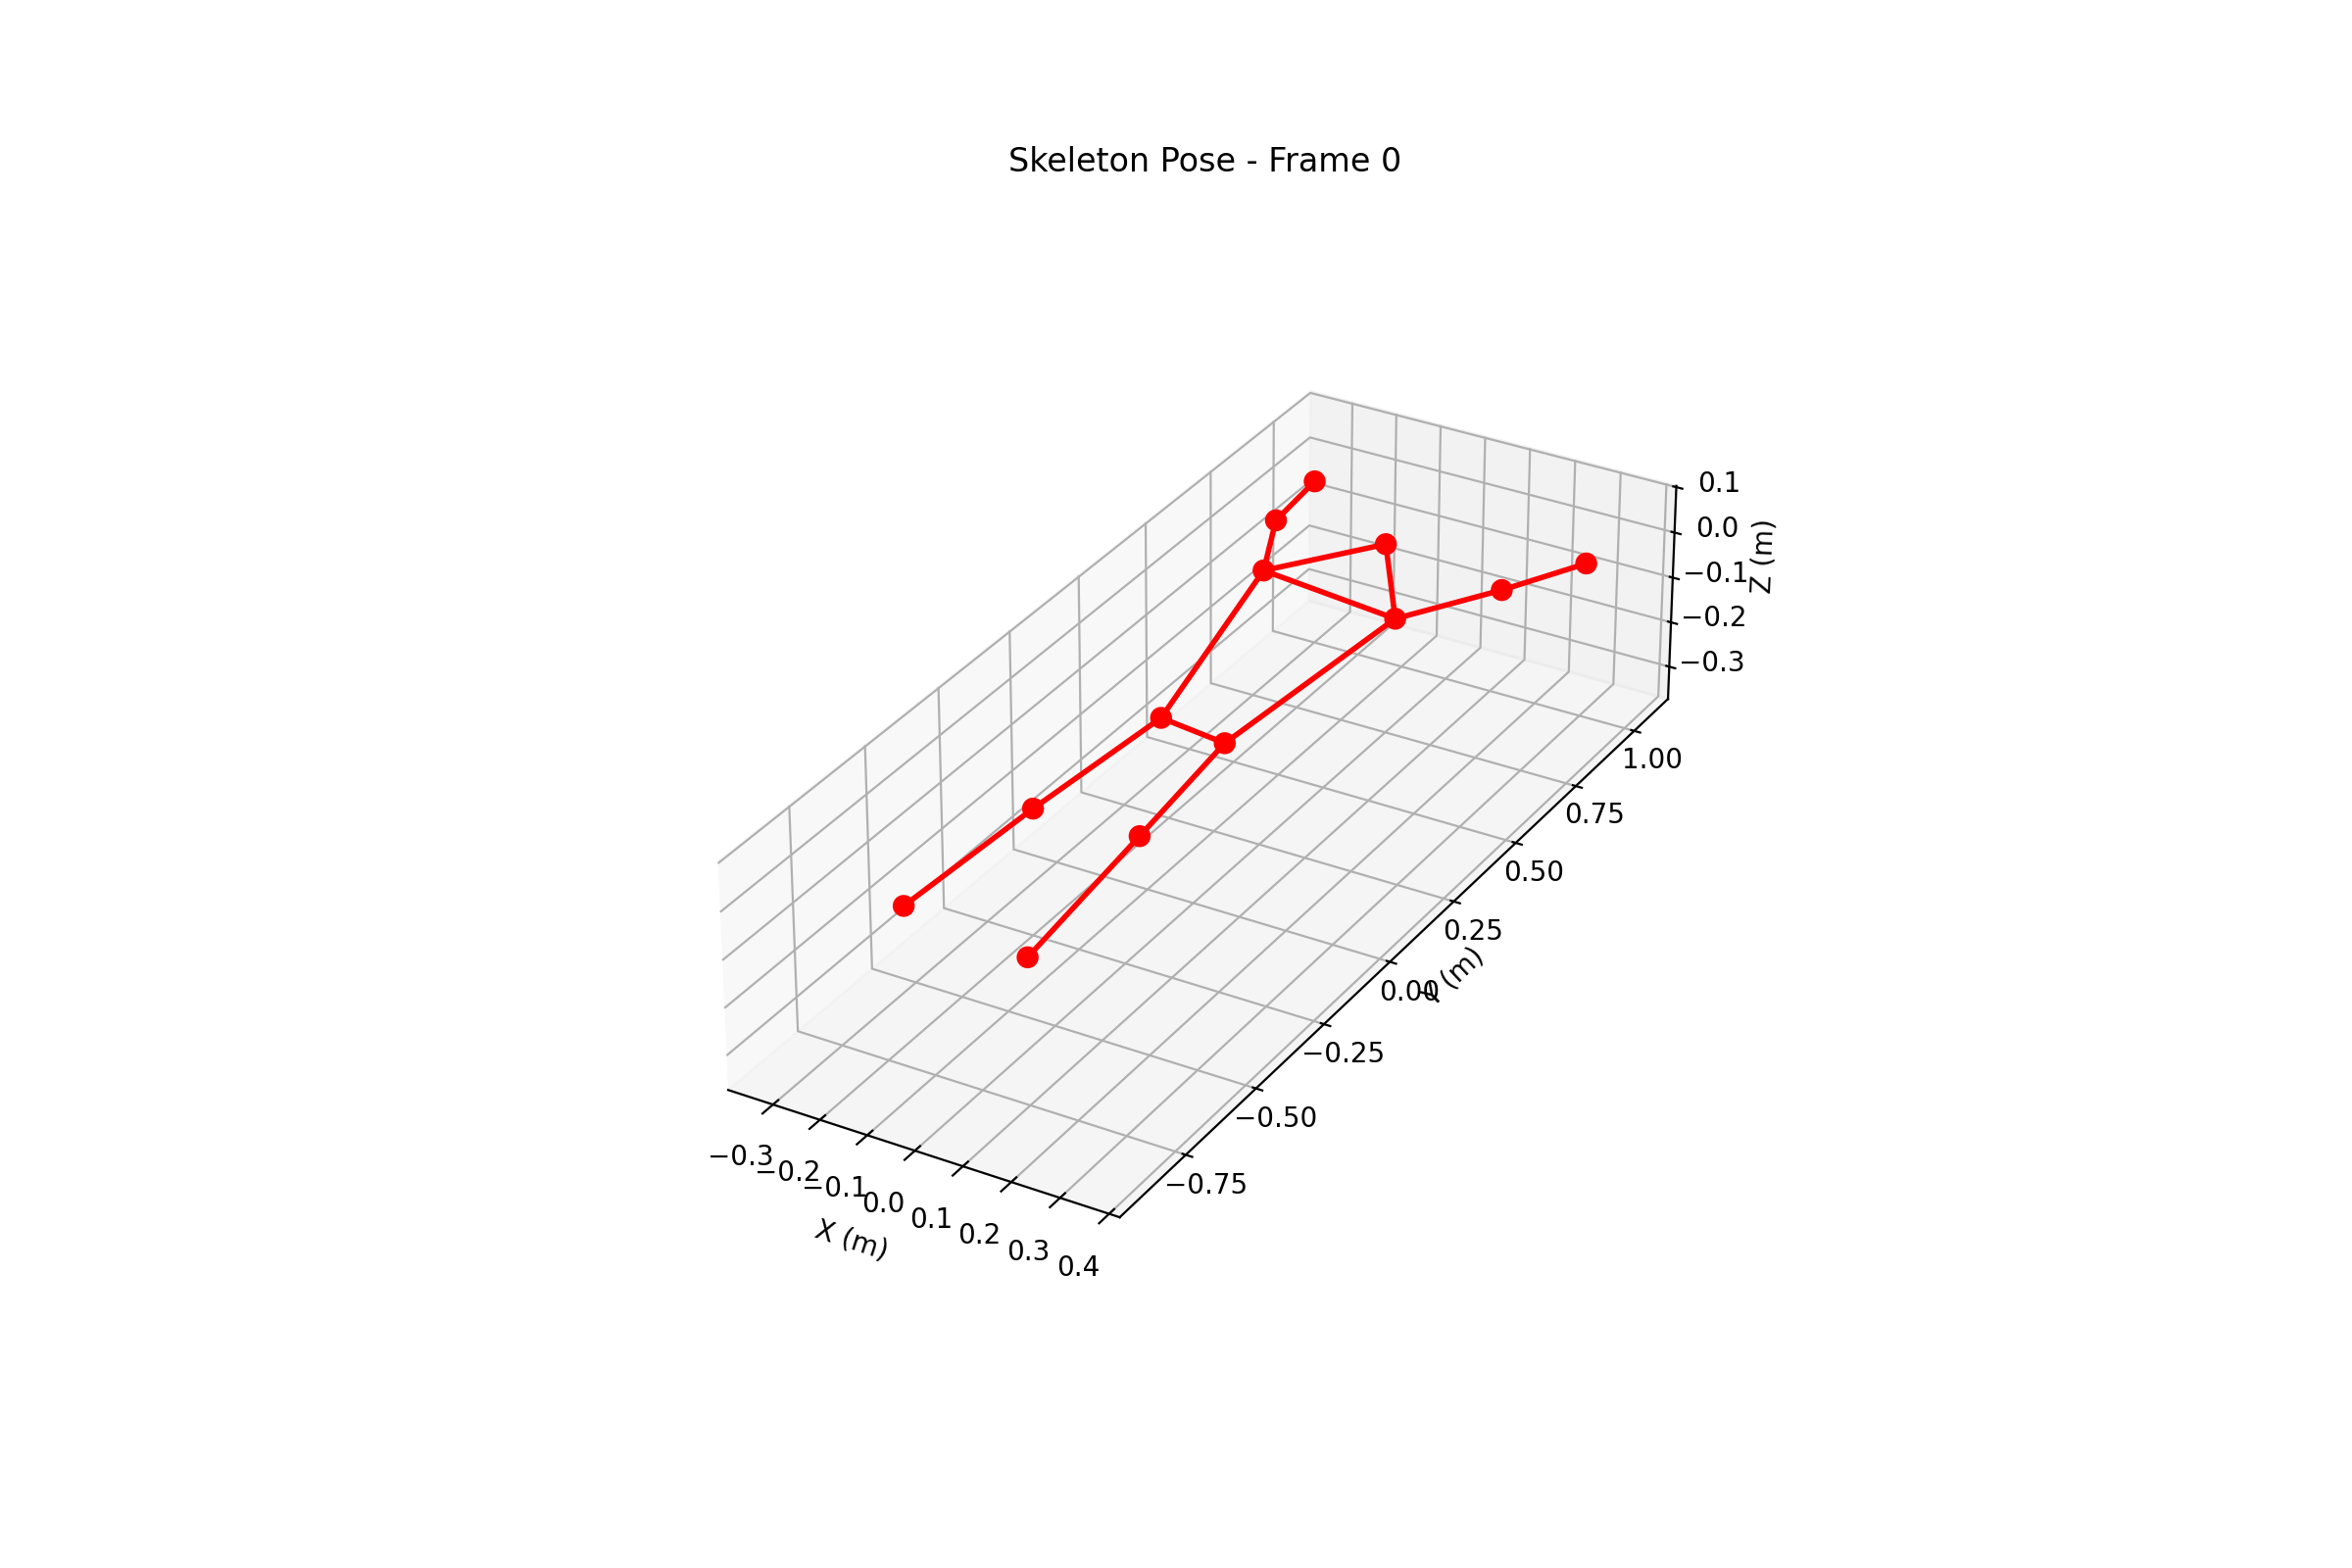

In [2]:
from IPython.display import Image

Image("../skeleton_animation.gif")

## Noice comparison


In this test we explored how noisy each node estimation is by training a model on Kinect X,Y to predict Kinect Z, and then repeating the same for MediaPipe X,Y to MediaPipe Z.

The motivation behind this comparison is that we model each coordinate as:

$$x_k = x + \mathcal{N}(0, \sigma_{x_k}) + \text{bias}(x_k)$$

We believe the pose estimator with the smallest $\sigma_{x_k}$ will perform better on the same neural network architecture and hyperparameters. The results are from a dense neural network evaluated with 5-fold cross-validation to reduce dependence on specific video splits. The bias terms was evaluated in the media pipe vs ground truth section. 

### Intresting traning results

In a few folds, such as fold 5 for MediaPipe, the validation loss is notably lower than the training loss, which suggests that certain videos may be substantially closer to ground truth.

**Fold 5/5** — train: 17,255 frames | val: 4,438 frames

| Epoch | Train Loss | Val Loss | Val MAE |
|-------|------------|----------|---------|
| 0     | 0.00887    | 0.00375  | 0.0426  |
| 50    | 0.00265    | 0.00193  | 0.0308  |
| 100   | 0.00253    | 0.00181  | 0.0296  |
| 150   | 0.00241    | 0.00156  | 0.0271  |
| 200   | 0.00219    | 0.00148  | 0.0264  |
| 250   | 0.00205    | 0.00118  | 0.0239  |



### Results 

**Test set metrics (mean over 5 folds):**

|           | Kinect mean | Kinect std | MediaPipe mean | MediaPipe std |
|-----------|-------------|------------|----------------|---------------|
| test_mse  | 0.00192     | 0.00012    | 0.00136        | 0.00004       |
| test_mae  | 0.03241     | 0.00104    | 0.02491        | 0.00039       |
| test_r2   | 0.90269     | 0.00621    | 0.93944        | 0.00197       |
| test_bias | 0.00863     | 0.00210    | −0.00001       | 0.00098       |

**Validation metrics over folds:**

| Metric   | MediaPipe mean ± std     | Kinect mean ± std        |
|----------|--------------------------|--------------------------|
| val_mse  | 0.00160 ± 0.00041        | 0.00270 ± 0.00068        |
| val_mae  | 0.02595 ± 0.00244        | 0.03513 ± 0.00247        |
| val_r2   | 0.92778 ± 0.01916        | 0.85466 ± 0.03657        |
| val_bias | −0.00026 ± 0.00217       | 0.00163 ± 0.00468        |

MediaPipe consistently outperforms Kinect across all metrics, with a ~27% lower test MAE (2.49 cm vs 3.24 cm) and a higher R² (0.939 vs 0.903). The near-zero bias for MediaPipe suggests its estimates are well-centered around the true values, whereas Kinect shows a small but consistent positive bias. A key structural difference is that MediaPipe centers Z values around the hip, which likely reduces the range and variance of the target values and may make Z prediction easier regardless of sensor noise.

## Future works

Ideas for what could be tested in the future:

* Use Bayesian optimization instead of gridsearch for more efficent searching
* Use some kind of noise filter on data, this would be for nodes that are completely of like in a video number 4 with foot.
